# Model Explainability — SHAP & LIME

We use **LightGBM** (our best model, ROC-AUC = 0.74) and explain *why* it predicts default risk for a customer.

| Tool | What it tells us |
|---|---|
| **SHAP** | How much each feature pushed the prediction up (toward default) or down (away from default) |
| **LIME** | A second, independent opinion — built differently from SHAP, used to sanity-check it |

**This notebook answers the deployment question directly:**
> "The model says this customer has a 78% default risk — *why*?"

That's exactly what `app.py` needs to show the end user after every prediction.

## 1. Setup

In [3]:
from intake import imports
!pip install -q shap lime

import os
import pandas as pd
import numpy as np
import joblib
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt

print("Libraries loaded")

Libraries loaded


## 2. Load Model & Data
Same `X_test` and `lightgbm_model.joblib` produced by `building_models.ipynb`.

In [7]:
model  = joblib.load(r"C:\Users\User\Desktop\XAI_System\models\lightgbm_model (1).joblib")
X_test = pd.read_parquet(r"C:\Users\User\Desktop\XAI_System\data\processed\X_test.parquet")
y_test = pd.read_parquet(r"C:\Users\User\Desktop\XAI_System\data\processed\y_test.parquet").squeeze()

print(f"Model: {type(model).__name__}")
print(f"Data: {X_test.shape}")

Model: LGBMClassifier
Data: (38172, 36)


## 3. Take a Sample
SHAP is slow on the full test set — 1000 customers is enough for reliable global patterns.

In [9]:
sample = X_test.sample(1000, random_state=42)
y_sample = y_test.loc[sample.index]

print(f"Sample size: {sample.shape}")

Sample size: (1000, 36)


## 4. Compute SHAP Values

Every customer × every feature gets a number:
- **Positive value** → pushed the prediction toward default
- **Negative value** → pushed the prediction away from default

The sum of all SHAP values + a baseline = the model's final prediction for that customer.

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# LightGBM binary classifier sometimes returns [class0, class1] — we want class 1 (default)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed for", shap_values.shape[0], "customers")

SHAP values computed for 1000 customers


C:\Users\User\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 5. Most Important Features Overall (Global)

Across ALL customers — which features does the model rely on the most when deciding default risk?

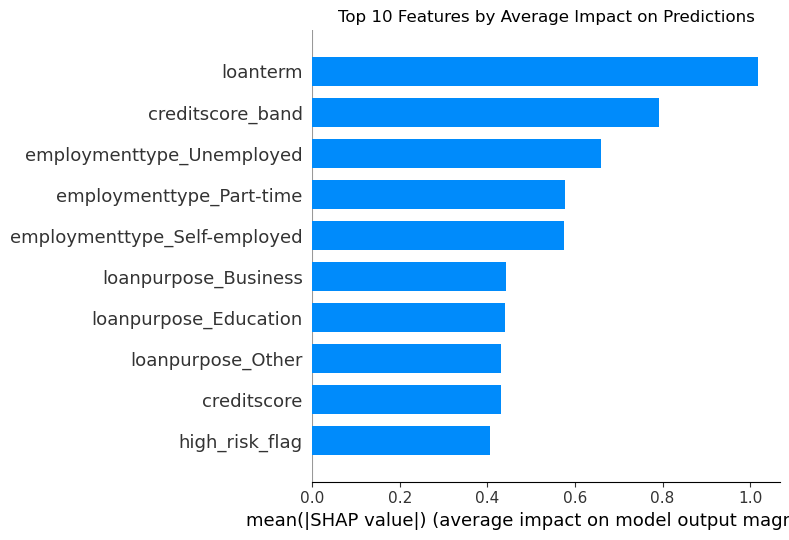

In [13]:
shap.summary_plot(shap_values, sample, plot_type="bar", max_display=10, show=False)
plt.title("Top 10 Features by Average Impact on Predictions")
plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\XAI_System\images\shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Direction of Impact (Beeswarm)

Same top features, but now we see **which direction** they push the prediction:
- 🔴 Red dot = high value for that feature
- 🔵 Blue dot = low value for that feature
- Right side = increases default risk · Left side = decreases default risk

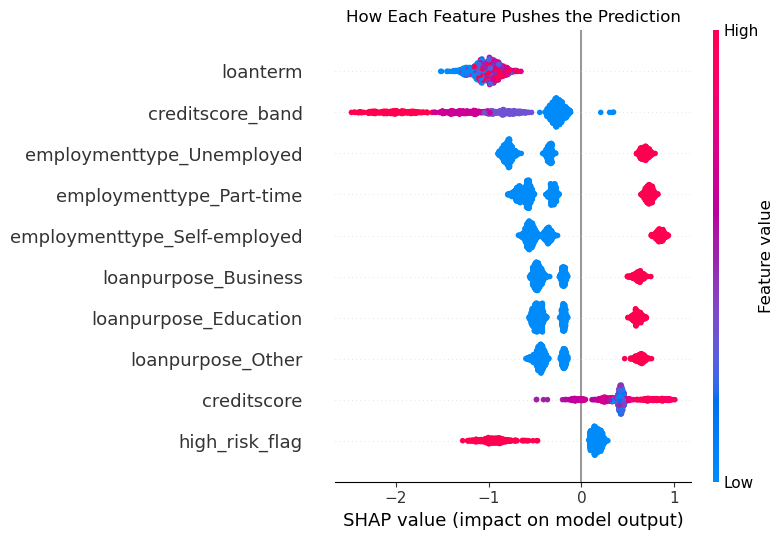

In [14]:
shap.summary_plot(shap_values, sample, max_display=10, show=False)
plt.title("How Each Feature Pushes the Prediction")
plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\XAI_System\images\shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Explaining ONE Customer's Prediction

> **This is what runs in `app.py` after every prediction.**  
> The model outputs a probability (e.g. "78% default risk") — the waterfall below is  
> the feature-by-feature breakdown of *why* it reached that number.

We pick the customer with the highest predicted default risk in our sample as an example.

In [15]:
# Find the customer with highest predicted default risk
probs = model.predict_proba(sample)[:, 1]
idx = probs.argmax()

print(f"Predicted default risk : {probs[idx]:.1%}")
print(f"Actual outcome : {'Default' if y_sample.iloc[idx] == 1 else 'No Default'}")

Predicted default risk : 90.4%
Actual outcome : Default


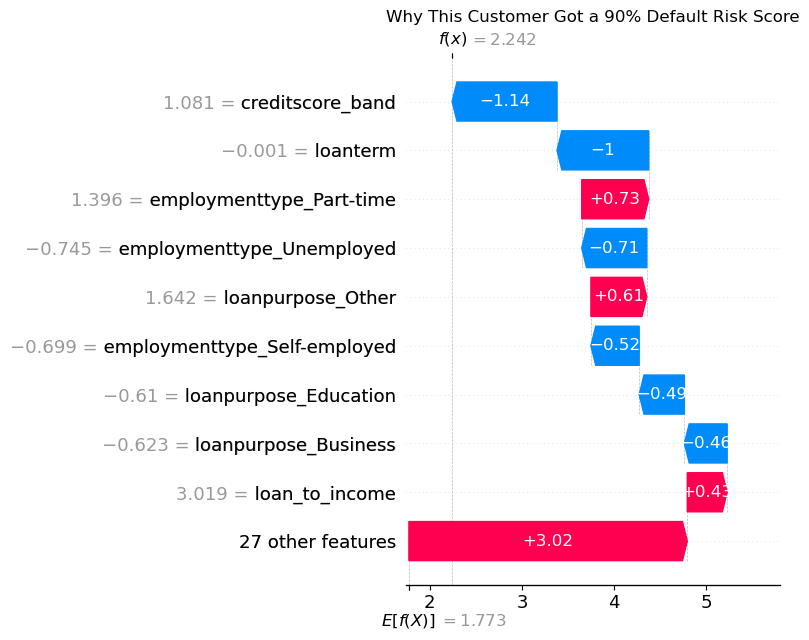

In [16]:
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

explanation = shap.Explanation(
    values = shap_values[idx],
    base_values = base_value,
    data = sample.iloc[idx].values,
    feature_names = sample.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=10, show=False)
plt.title(f"Why This Customer Got a {probs[idx]:.0%} Default Risk Score")
plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\XAI_System\images\shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.1 · Turning SHAP Numbers into a Sentence

A waterfall plot is great for us, but the **end user in the app** needs a plain-English sentence.  
This is the exact logic `app.py` should use to generate the explanation text shown to the user.

In [17]:
def explain_prediction(shap_row, feature_names, top_n=3):
    """
    Turns one customer's SHAP values into a human-readable explanation.
    shap_row: 1D array of SHAP values for one customer (same order as feature_names)
    """
    pairs = list(zip(feature_names, shap_row))
    # Sort by absolute impact, biggest first
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_n]

    lines = []
    for feature, value in pairs_sorted:
        direction = "increased" if value > 0 else "decreased"
        lines.append(f"  • {feature} {direction} the risk (impact: {value:+.3f})")
    return "\n".join(lines)

print(f"Customer risk score: {probs[idx]:.1%}\n")
print("Top reasons behind this decision:")
print(explain_prediction(shap_values[idx], sample.columns.tolist()))

Customer risk score: 90.4%

Top reasons behind this decision:
  • creditscore_band decreased the risk (impact: -1.139)
  • loanterm decreased the risk (impact: -0.995)
  • employmenttype_Part-time increased the risk (impact: +0.728)


**This is the function to copy into `app.py`.**  
Call it right after `model.predict_proba(new_customer)` and show the output text next to the prediction —  
no need to render a SHAP plot inside Streamlit if you just want a quick text explanation (though the  
waterfall plot can also be shown, as already done in `app.py`).

## 8. LIME — A Second Opinion on the Same Customer

LIME explains predictions in a completely different way from SHAP (it builds a small local model  
around this one customer). If SHAP and LIME point to the same top features, the explanation is trustworthy.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


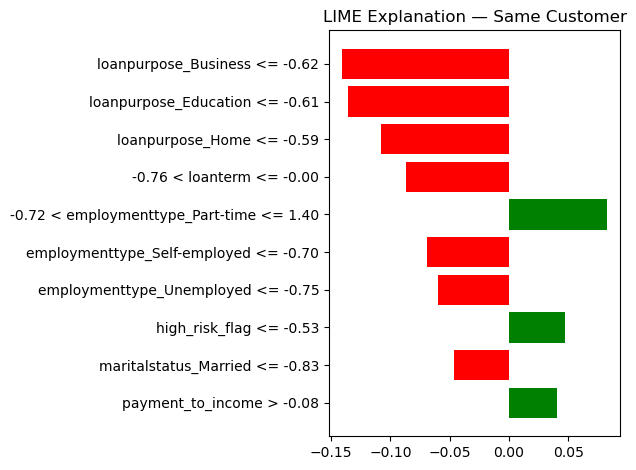

In [18]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = sample.values,
    feature_names = sample.columns.tolist(),
    class_names = ["No Default", "Default"],
    mode = "classification"
)

lime_exp = lime_explainer.explain_instance(
    data_row  = sample.iloc[idx].values,
    predict_fn = model.predict_proba,
    num_features = 10
)

lime_exp.as_pyplot_figure()
plt.title("LIME Explanation — Same Customer")
plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\XAI_System\images\lime_explanation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary

| Plot | What it tells us |
|---|---|
| SHAP Bar | Which features the model relies on most, across all customers |
| SHAP Beeswarm | Whether a high or low value of each feature increases or decreases risk |
| SHAP Waterfall | Step-by-step breakdown of **one** customer's prediction — this is what powers the explanation in `app.py` |
| `explain_prediction()` | Converts SHAP numbers into a plain-English sentence for the end user |
| LIME | Independent confirmation — same top features as SHAP = reliable explanation |

**How this connects to deployment:**
1. `app.py` loads the same model + scaler
2. User enters customer data → `model.predict_proba()` → risk score (e.g. 78%)
3. `explainer.shap_values()` on that one customer → feed into `explain_prediction()`
4. Show the risk score + the top 3 reasons to the user — turning a black-box number into a clear decision.